In [1]:
from datetime import datetime
import fsspec
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import multiprocessing
import numpy as np
import xarray as xr

In [5]:
def load_files(lookup: str) -> xr.Dataset:
    local = fsspec.filesystem('file')
    files = local.glob(lookup)
    with multiprocessing.Pool() as pool:
        ds_list = pool.map(xr.open_dataset, files)
    try:
        ds = xr.combine_by_coords(ds_list, combine_attrs = 'drop_conflicts')
    except:
        ds = xr.concat(ds_list, dim = 'time', combine_attrs = 'drop_conflicts')
        ds = ds.drop_duplicates(dim = 'time')
    ds = ds.sortby('time')
    return ds

In [6]:
apollo = load_files('C:/Users/annar/Box/pco2_skq/data/ship_files/*APOLLO*/*APOLLO*.nc')

KeyError: "No variable named 'time'. Variables on the dataset include []"

In [4]:
apollo = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*APOLLO*/*APOLLO*.nc')
apollo = apollo[['air_temperature','apollo_sbe45_sea_water_temperature','apollo_sbe45_sea_water_practical_salinity','barometric_pressure','fco2','pco2','sea_surface_temperature','sea_water_practical_salinity','water_vapor_pressure', 'xco2_corr','li7815_h2o','li7815_xco2']]
apollo = apollo.sel(time = slice(datetime(2024,8,14,12,0,0,0),None))

apollo_air = apollo.sel(sample_source = 'air')
apollo_air = apollo_air.rolling({'time':16}, center = 'True', min_periods = 1).median(skipna = True)
apollo_air = apollo_air.resample({'time': '15min'}).mean( skipna = True)

apollo_sea = apollo.sel(sample_source = 'seawater')
apollo_sea = apollo_sea.rolling({'time':16}, center = 'True', min_periods = 1).median(skipna = True)
apollo_sea = apollo_sea.resample({'time': '15min'}).mean( skipna = True)

In [5]:
ldeo = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*LDEO*/*LDEO*.nc')
ldeo = ldeo.sel(time = slice(datetime(2024,8,14,12,0,0,0),None))

ldeo_air = ldeo.sel(sample_source = 'air')
ldeo_air = ldeo_air.rolling({'time':16}, center = 'True', min_periods = 1).median(skipna = True)
ldeo_air = ldeo_air.resample({'time': '15min'}).mean( skipna = True)

ldeo_sea = ldeo.sel(sample_source = 'seawater')
ldeo_sea = ldeo_sea.rolling({'time':16}, center = 'True', min_periods = 1).median(skipna = True)
ldeo_sea = ldeo_sea.resample({'time': '15min'}).mean( skipna = True)

In [6]:
delta_sw_x = apollo_sea.xco2_corr-ldeo_sea.xco2_corr
delta_at_x = apollo_air.xco2_corr-ldeo_air.xco2_corr

In [7]:
delta_sw = apollo_sea.fco2-ldeo_sea.fco2
delta_at = apollo_air.fco2-ldeo_air.fco2

In [53]:
plt.close('all')

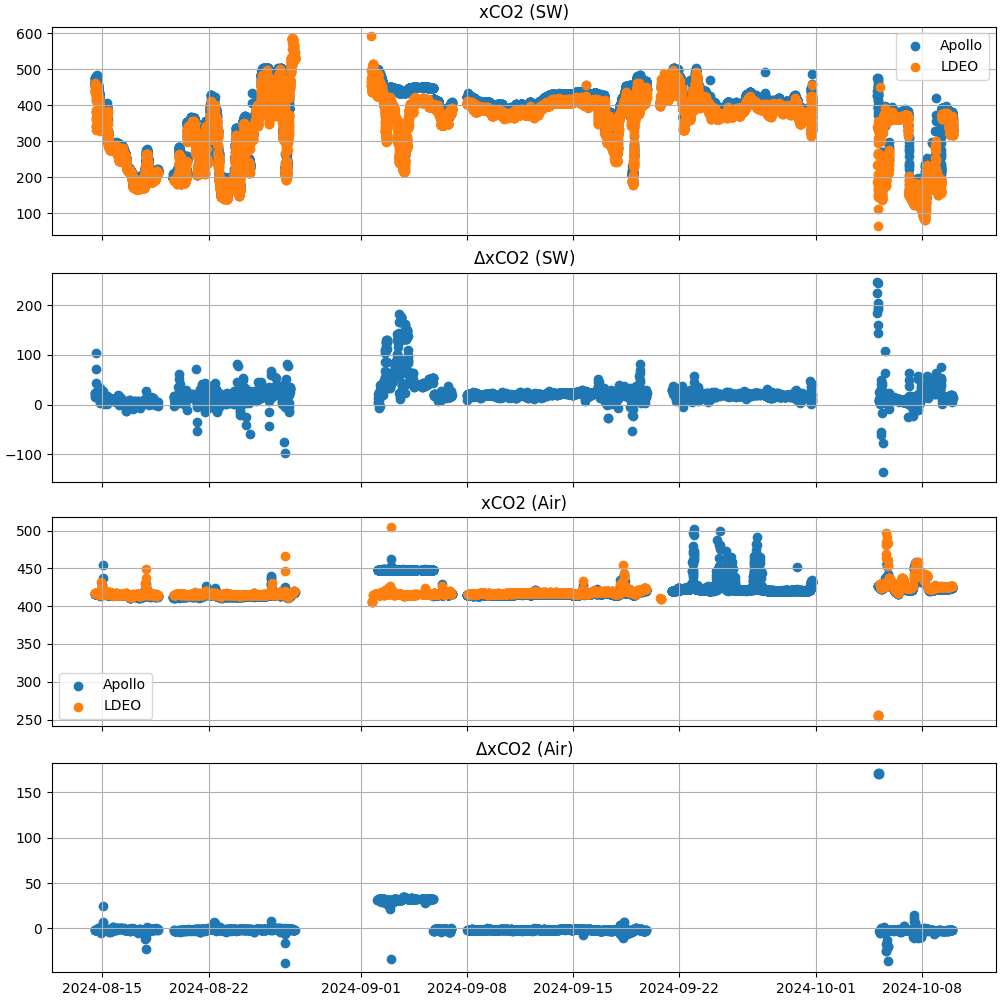

In [54]:
%matplotlib widget

fig, ax = plt.subplots(4,1,figsize = (10,10),sharex = True, constrained_layout = True)
ax[0].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.xco2_corr.where(apollo.sample_source == 'seawater'), label='Apollo')
ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.xco2_corr.where(ldeo.sample_source == 'seawater'), label='LDEO')
ax[0].set_title('xCO2 (SW)')
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo_sea.time, delta_sw_x)
ax[1].set_title('$\Delta$xCO2 (SW)')
ax[1].grid()

ax[2].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.xco2_corr.where(apollo.sample_source == 'air'), label='Apollo')
ax[2].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.xco2_corr.where(ldeo.sample_source == 'air'), label='LDEO')
ax[2].set_title('xCO2 (Air)')
ax[2].grid()
ax[2].legend()

ax[3].scatter(apollo_air.time, delta_at_x)
ax[3].set_title('$\Delta$xCO2 (Air)')
ax[3].grid()

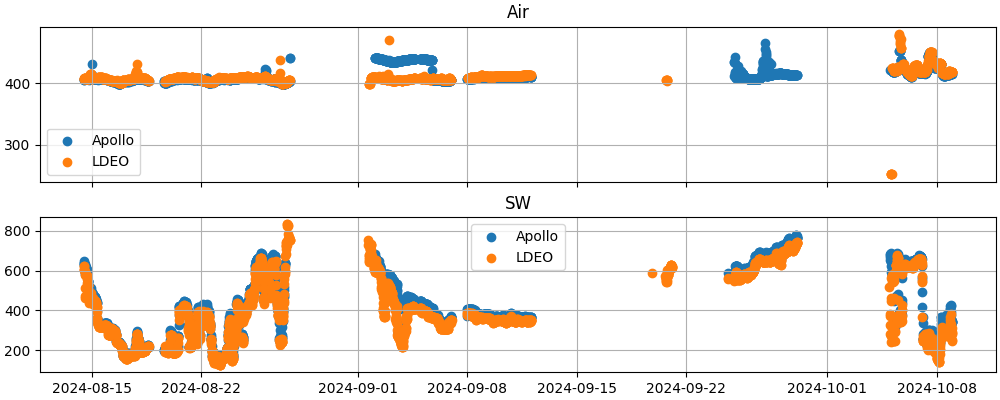

In [9]:
%matplotlib widget

fig, ax = plt.subplots(2,1,figsize = (10,4),sharex = True, constrained_layout = True)
ax[0].scatter(apollo_air.time, apollo_air.fco2, label='Apollo')
ax[0].scatter(ldeo_air.time, ldeo_air.fco2, label='LDEO')
ax[0].set_title('Air')
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo_sea.time, apollo_sea.fco2, label='Apollo')
ax[1].scatter(ldeo_sea.time, ldeo_sea.fco2, label='LDEO')
ax[1].set_title('SW')
ax[1].grid()
ax[1].legend()

In [14]:
ldeo_air_aug = ldeo_air.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))
ldeo_sea_aug = ldeo_sea.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))

ldeo_air_se1 = ldeo_air.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))
ldeo_sea_se1 = ldeo_sea.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))

ldeo_air_se2 = ldeo_air.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))
ldeo_sea_se2 = ldeo_sea.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))

ldeo_air_oct = ldeo_air.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))
ldeo_sea_oct = ldeo_sea.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))

apollo_air_aug = apollo_air.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))
apollo_sea_aug = apollo_sea.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))

apollo_air_se1 = apollo_air.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))
apollo_sea_se1 = apollo_air.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))

apollo_air_se2 = apollo_air.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))
apollo_sea_se2 = apollo_sea.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))

apollo_air_oct = apollo_air.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))
apollo_sea_oct = apollo_sea.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))

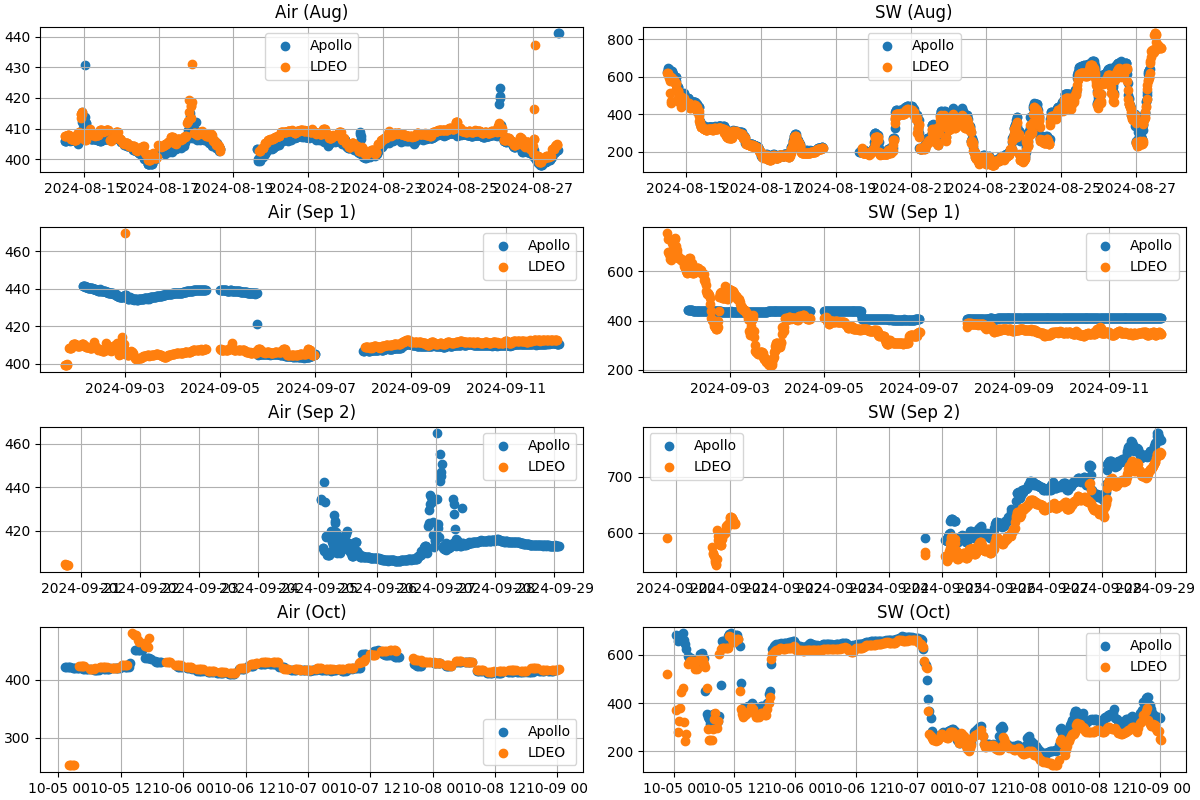

In [15]:
%matplotlib widget

fig, ax = plt.subplots(4,2,figsize = (12,8), constrained_layout = True)
ax[0,0].scatter(apollo_air_aug.time, apollo_air_aug.fco2, label='Apollo')
ax[0,0].scatter(ldeo_air_aug.time, ldeo_air_aug.fco2, label='LDEO')
ax[0,0].set_title('Air (Aug)')
ax[0,0].grid()
ax[0,0].legend()

ax[0,1].scatter(apollo_sea_aug.time, apollo_sea_aug.fco2, label='Apollo')
ax[0,1].scatter(ldeo_sea_aug.time, ldeo_sea_aug.fco2, label='LDEO')
ax[0,1].set_title('SW (Aug)')
ax[0,1].grid()
ax[0,1].legend()

ax[1,0].scatter(apollo_air_se1.time, apollo_air_se1.fco2, label='Apollo')
ax[1,0].scatter(ldeo_air_se1.time, ldeo_air_se1.fco2, label='LDEO')
ax[1,0].set_title('Air (Sep 1)')
ax[1,0].grid()
ax[1,0].legend()

ax[1,1].scatter(apollo_sea_se1.time, apollo_sea_se1.fco2, label='Apollo')
ax[1,1].scatter(ldeo_sea_se1.time, ldeo_sea_se1.fco2, label='LDEO')
ax[1,1].set_title('SW (Sep 1)')
ax[1,1].grid()
ax[1,1].legend()

ax[2,0].scatter(apollo_air_se2.time, apollo_air_se2.fco2, label='Apollo')
ax[2,0].scatter(ldeo_air_se2.time, ldeo_air_se2.fco2, label='LDEO')
ax[2,0].set_title('Air (Sep 2)')
ax[2,0].grid()
ax[2,0].legend()

ax[2,1].scatter(apollo_sea_se2.time, apollo_sea_se2.fco2, label='Apollo')
ax[2,1].scatter(ldeo_sea_se2.time, ldeo_sea_se2.fco2, label='LDEO')
ax[2,1].set_title('SW (Sep 2)')
ax[2,1].grid()
ax[2,1].legend()

ax[3,0].scatter(apollo_air_oct.time, apollo_air_oct.fco2, label='Apollo')
ax[3,0].scatter(ldeo_air_oct.time, ldeo_air_oct.fco2, label='LDEO')
ax[3,0].set_title('Air (Oct)')
ax[3,0].grid()
ax[3,0].legend()

ax[3,1].scatter(apollo_sea_oct.time, apollo_sea_oct.fco2, label='Apollo')
ax[3,1].scatter(ldeo_sea_oct.time, ldeo_sea_oct.fco2, label='LDEO')
ax[3,1].set_title('SW (Oct)')
ax[3,1].grid()
ax[3,1].legend()

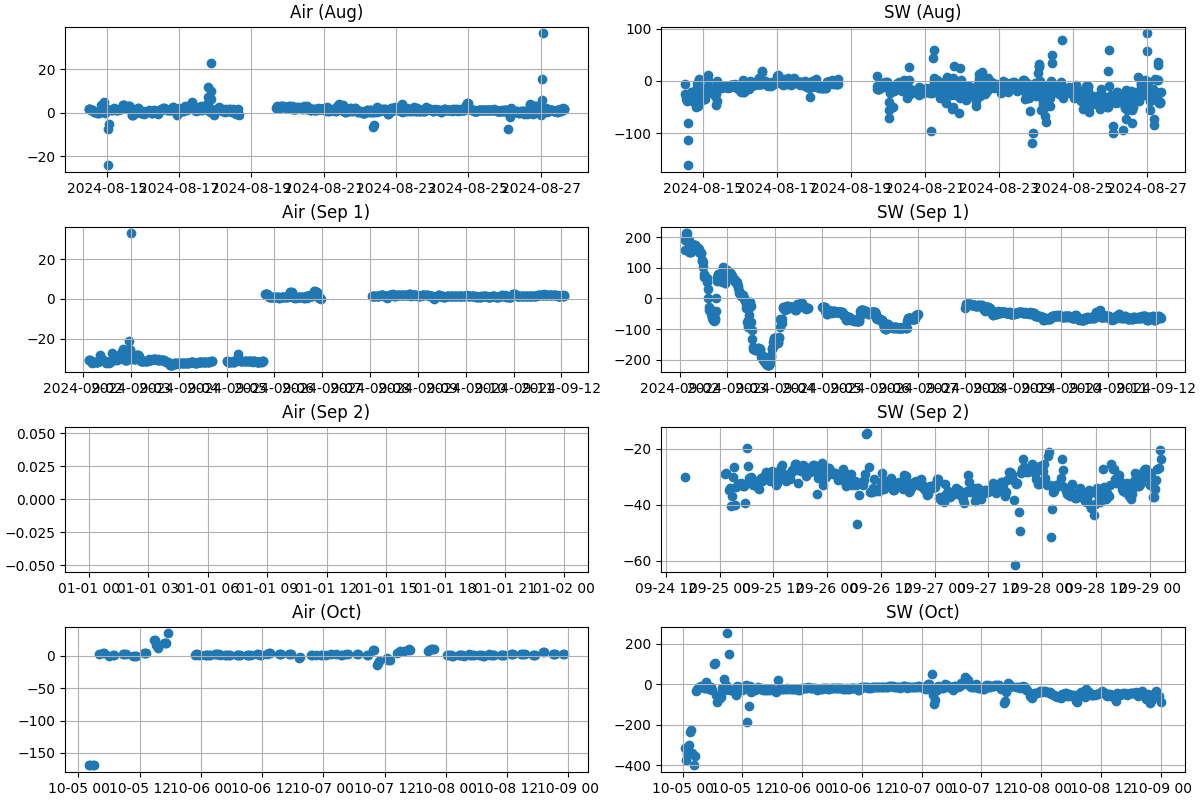

In [16]:
%matplotlib widget

fig, ax = plt.subplots(4,2,figsize = (12,8), constrained_layout = True)
ax[0,0].scatter(apollo_air_aug.time, ldeo_air_aug.fco2-apollo_air_aug.fco2)
ax[0,0].set_title('Air (Aug)')
ax[0,0].grid()

ax[0,1].scatter(apollo_sea_aug.time, ldeo_sea_aug.fco2-apollo_sea_aug.fco2)
ax[0,1].set_title('SW (Aug)')
ax[0,1].grid()

ax[1,0].scatter(apollo_air_se1.time, ldeo_air_se1.fco2-apollo_air_se1.fco2)
ax[1,0].set_title('Air (Sep 1)')
ax[1,0].grid()

ax[1,1].scatter(apollo_sea_se1.time, ldeo_sea_se1.fco2-apollo_sea_se1.fco2)
ax[1,1].set_title('SW (Sep 1)')
ax[1,1].grid()

ax[2,0].scatter(apollo_air_se2.time, ldeo_air_se2.fco2-apollo_air_se2.fco2)
ax[2,0].set_title('Air (Sep 2)')
ax[2,0].grid()

ax[2,1].scatter(apollo_sea_se2.time, ldeo_sea_se2.fco2-apollo_sea_se2.fco2)
ax[2,1].set_title('SW (Sep 2)')
ax[2,1].grid()

ax[3,0].scatter(apollo_air_oct.time, ldeo_air_oct.fco2-apollo_air_oct.fco2)
ax[3,0].set_title('Air (Oct)')
ax[3,0].grid()

ax[3,1].scatter(apollo_sea_oct.time, ldeo_sea_oct.fco2-apollo_sea_oct.fco2)
ax[3,1].set_title('SW (Oct)')
ax[3,1].grid()

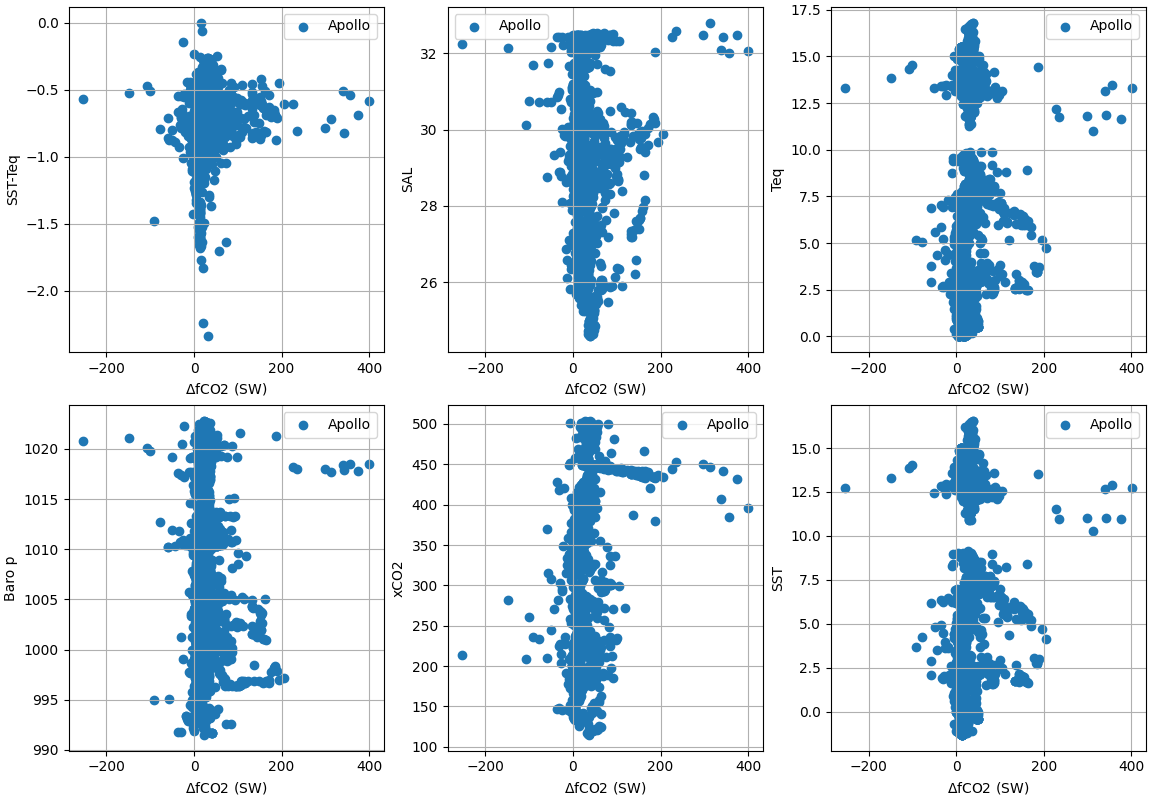

In [17]:
%matplotlib widget

fig, ax = plt.subplots(2,3,figsize = (11.5,8), constrained_layout = True)
ax[0,0].scatter(delta_sw, apollo_sea.sea_surface_temperature-apollo_sea.apollo_sbe45_sea_water_temperature, label='Apollo')
ax[0,0].set_ylabel('SST-Teq')
ax[0,0].set_xlabel('$\Delta$fCO2 (SW)')
ax[0,0].grid()
ax[0,0].legend()

ax[1,0].scatter(delta_sw, apollo_sea.barometric_pressure, label='Apollo')
ax[1,0].set_ylabel('Baro p')
ax[1,0].set_xlabel('$\Delta$fCO2 (SW)')
ax[1,0].grid()
ax[1,0].legend()

ax[0,1].scatter(delta_sw, apollo_sea.apollo_sbe45_sea_water_practical_salinity, label='Apollo')
ax[0,1].set_ylabel('SAL')
ax[0,1].set_xlabel('$\Delta$fCO2 (SW)')
ax[0,1].grid()
ax[0,1].legend()

ax[1,1].scatter(delta_sw, apollo_sea.xco2_corr, label='Apollo')
ax[1,1].set_ylabel('xCO2')
ax[1,1].set_xlabel('$\Delta$fCO2 (SW)')
ax[1,1].grid()
ax[1,1].legend()

ax[0,2].scatter(delta_sw, apollo_sea.apollo_sbe45_sea_water_temperature, label='Apollo')
ax[0,2].set_ylabel('Teq')
ax[0,2].set_xlabel('$\Delta$fCO2 (SW)')
ax[0,2].grid()
ax[0,2].legend()

ax[1,2].scatter(delta_sw, apollo_sea.sea_surface_temperature, label='Apollo')
ax[1,2].set_ylabel('SST')
ax[1,2].set_xlabel('$\Delta$fCO2 (SW)')
ax[1,2].grid()
ax[1,2].legend()

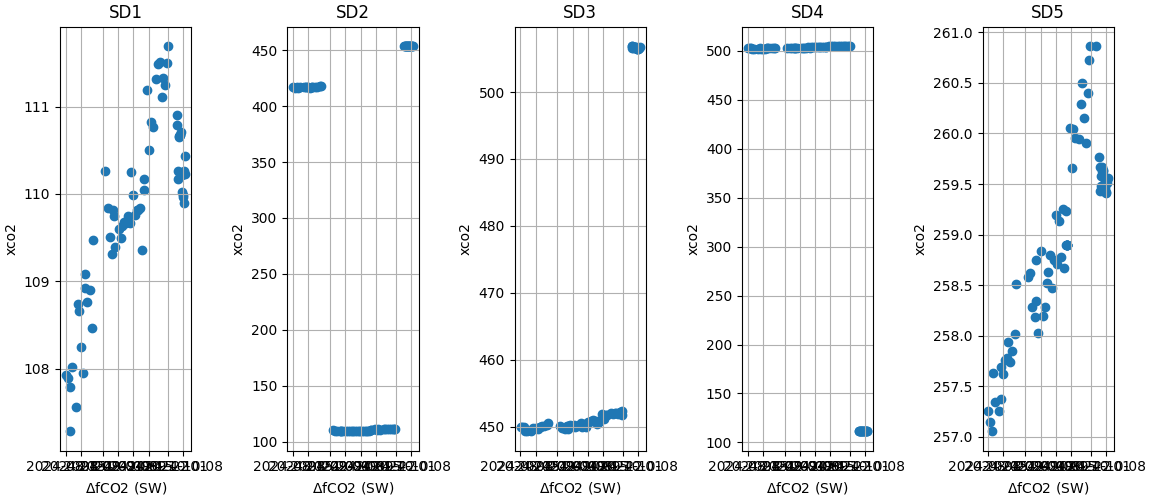

In [24]:
fig, ax = plt.subplots(1,5,figsize = (11.5,5), constrained_layout = True)
ax[0].scatter(apollo.time.where((apollo.sample_source == 'sd1') & (apollo.li7815_xco2 > 50)), apollo.li7815_xco2.where((apollo.sample_source == 'sd1') & (apollo.li7815_xco2 > 50)), label='Apollo')
ax[0].set_ylabel('xco2')
ax[0].set_title('SD1')
ax[0].set_xlabel('$\Delta$fCO2 (SW)')
ax[0].grid()

ax[1].scatter(apollo.time.where((apollo.sample_source == 'sd2') & (apollo.li7815_xco2 > 50)), apollo.li7815_xco2.where((apollo.sample_source == 'sd2') & (apollo.li7815_xco2 > 50)), label='Apollo')
ax[1].set_ylabel('xco2')
ax[1].set_title('SD2')
ax[1].set_xlabel('$\Delta$fCO2 (SW)')
ax[1].grid()

ax[2].scatter(apollo.time.where((apollo.sample_source == 'sd3') & (apollo.li7815_xco2 > 50)), apollo.li7815_xco2.where((apollo.sample_source == 'sd3') & (apollo.li7815_xco2 > 50)), label='Apollo')
ax[2].set_ylabel('xco2')
ax[2].set_title('SD3')
ax[2].set_xlabel('$\Delta$fCO2 (SW)')
ax[2].grid()

ax[3].scatter(apollo.time.where((apollo.sample_source == 'sd4') & (apollo.li7815_xco2 > 50)), apollo.li7815_xco2.where((apollo.sample_source == 'sd4') & (apollo.li7815_xco2 > 50)), label='Apollo')
ax[3].set_ylabel('xco2')
ax[3].set_title('SD4')
ax[3].set_xlabel('$\Delta$fCO2 (SW)')
ax[3].grid()

ax[4].scatter(apollo.time.where((apollo.sample_source == 'sd5') & (apollo.li7815_xco2 > 50)), apollo.li7815_xco2.where((apollo.sample_source == 'sd5') & (apollo.li7815_xco2 > 50)), label='Apollo')
ax[4].set_ylabel('xco2')
ax[4].set_title('SD5')
ax[4].set_xlabel('$\Delta$fCO2 (SW)')
ax[4].grid()

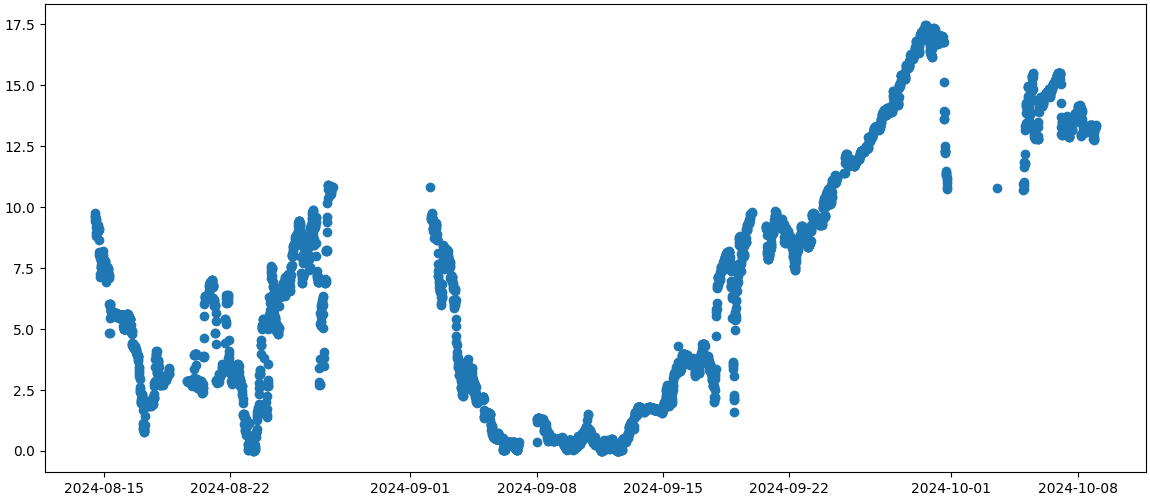

In [45]:
fig,ax = plt.subplots(1,1,figsize = (11.5,5), constrained_layout = True)
ax.scatter(apollo_sea.time,apollo_sea.apollo_sbe45_sea_water_temperature)

Teq:  [15.4898]
Sal:  [32.03634]
Apollo pCO2:  [672.43589566]
LDEO pCO2:  [661.55989007]


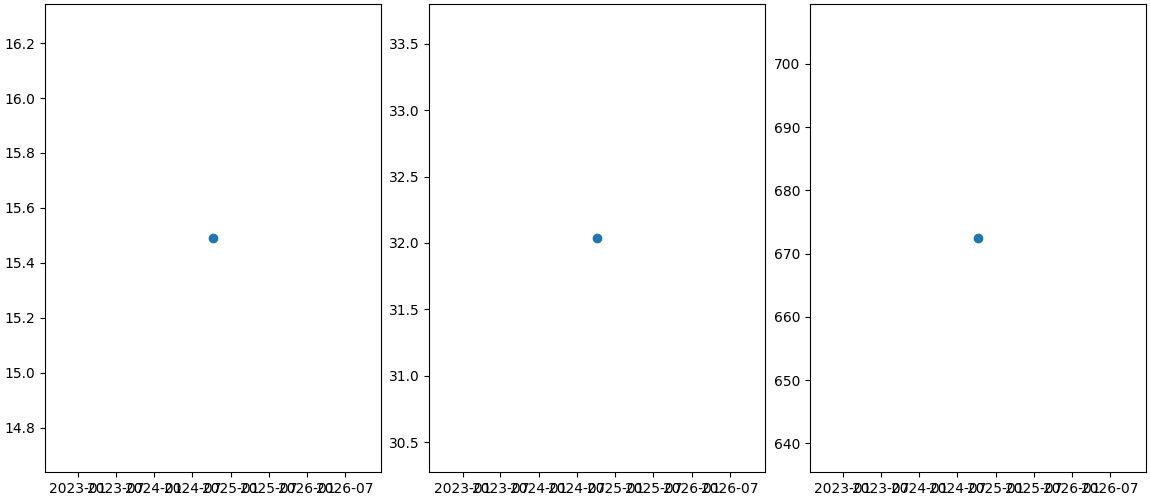

In [42]:
fig,ax = plt.subplots(1,3,figsize = (11.5,5), constrained_layout = True)
ax[0].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))),apollo_sea.apollo_sbe45_sea_water_temperature.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))))

ax[1].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))),apollo_sea.apollo_sbe45_sea_water_practical_salinity.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))))

ax[2].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))),apollo_sea.pco2.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))))

print("Teq: ",apollo_sea.apollo_sbe45_sea_water_temperature.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))).values)
print("Sal: ",apollo_sea.apollo_sbe45_sea_water_practical_salinity.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))).values)
print("Apollo pCO2: ",apollo_sea.pco2.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))).values)
print("LDEO pCO2: ",ldeo_sea.pco2.sel(time = slice(datetime(2024,10,7,0,0,0,0),datetime(2024,10,7,0,10,0,0))).values)

Teq:  [13.3107125]
Sal:  [32.4827625]
Apollo pCO2:  [334.16733997]
LDEO pCO2:  [285.46113065]


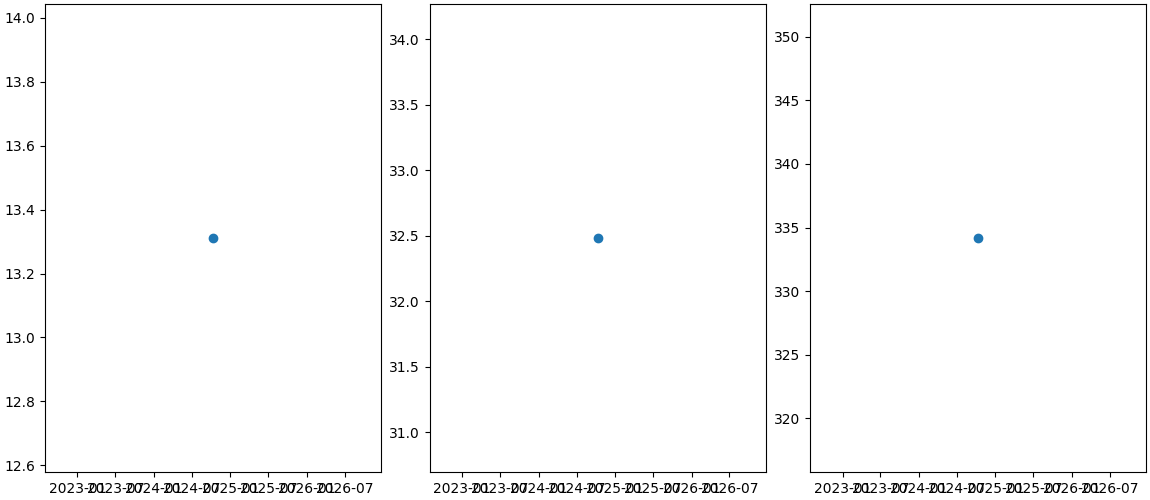

In [44]:
fig,ax = plt.subplots(1,3,figsize = (11.5,5), constrained_layout = True)
ax[0].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))),apollo_sea.apollo_sbe45_sea_water_temperature.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))))

ax[1].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))),apollo_sea.apollo_sbe45_sea_water_practical_salinity.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))))

ax[2].scatter(apollo_sea.time.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))),apollo_sea.pco2.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))))

print("Teq: ",apollo_sea.apollo_sbe45_sea_water_temperature.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))).values)
print("Sal: ",apollo_sea.apollo_sbe45_sea_water_practical_salinity.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))).values)
print("Apollo pCO2: ",apollo_sea.pco2.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))).values)
print("LDEO pCO2: ",ldeo_sea.pco2.sel(time = slice(datetime(2024,10,8,17,30,0,0),datetime(2024,10,8,17,40,0,0))).values)

In [82]:
triplet = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*TRIPLET*/*TRIPLET*.nc')
triplet = triplet[['fluorometric_cdom','fluorometric_chlorophyll_a']]
triplet = triplet.sel(time = slice(datetime(2024,8,14,12,0,0,0),None))
triplet = triplet.rolling({'time':61}, center = 'True', min_periods = 1).median()
triplet = triplet.resample({'time': '20min'}).mean(skipna = True)

In [83]:
oxy = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*OPTODE*/*OPTODE*.nc')
oxy = oxy[['dissolved_oxygen','estimated_oxygen_saturation']]
oxy = oxy.sel(time = slice(datetime(2024,8,14,12,0,0,0),None))
oxy = oxy.rolling({'time':61}, center = 'True', min_periods = 1).median()
oxy = oxy.resample({'time': '20min'}).mean(skipna = True)

In [84]:
nit = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*SUNA*/*SUNA*.nc')
nit = nit[['nitrate']]
nit = nit.sel(time = slice(datetime(2024,8,14,12,0,0,0),None))
nit = nit.rolling({'time':21}, center = 'True', min_periods = 1).median()
nit = nit.resample({'time': '20min'}).mean(skipna = True)

Text(0.5, 1.0, 'Nitrate')

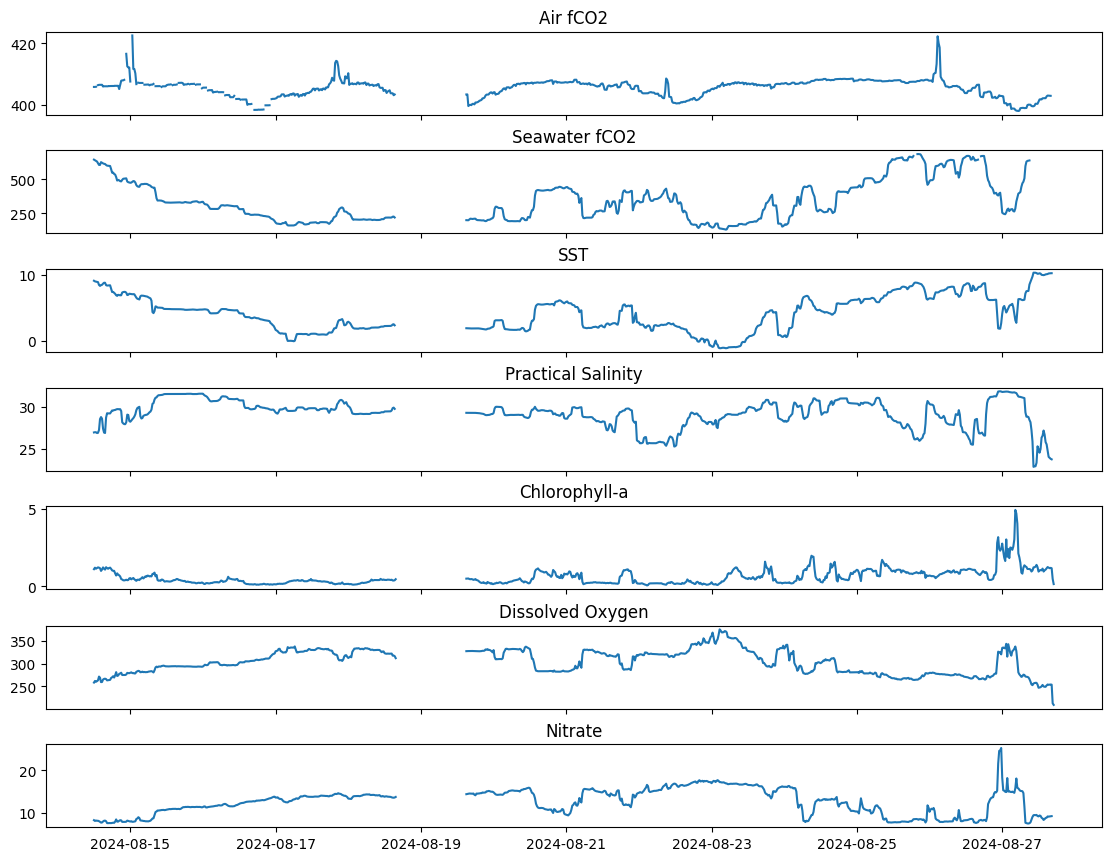

In [88]:
fig, ax = plt.subplots(7,1,figsize = (11,8.5),sharex = True, constrained_layout = True)
ax[0].plot(air.time, air.fco2)
ax[1].plot(sw.time, sw.fco2)
ax[2].plot(sw.time, sw.sea_surface_temperature)
ax[3].plot(sw.time, sw.sea_water_practical_salinity)
ax[4].plot(triplet.time, triplet.fluorometric_chlorophyll_a)
ax[5].plot(oxy.time, oxy.dissolved_oxygen)
ax[6].plot(nit.time, nit.nitrate)



ax[0].set_title('Air fCO2')
ax[1].set_title('Seawater fCO2')
ax[2].set_title('SST')
ax[3].set_title('Practical Salinity')
ax[4].set_title('Chlorophyll-a')
ax[5].set_title('Dissolved Oxygen')
ax[6].set_title('Nitrate')
